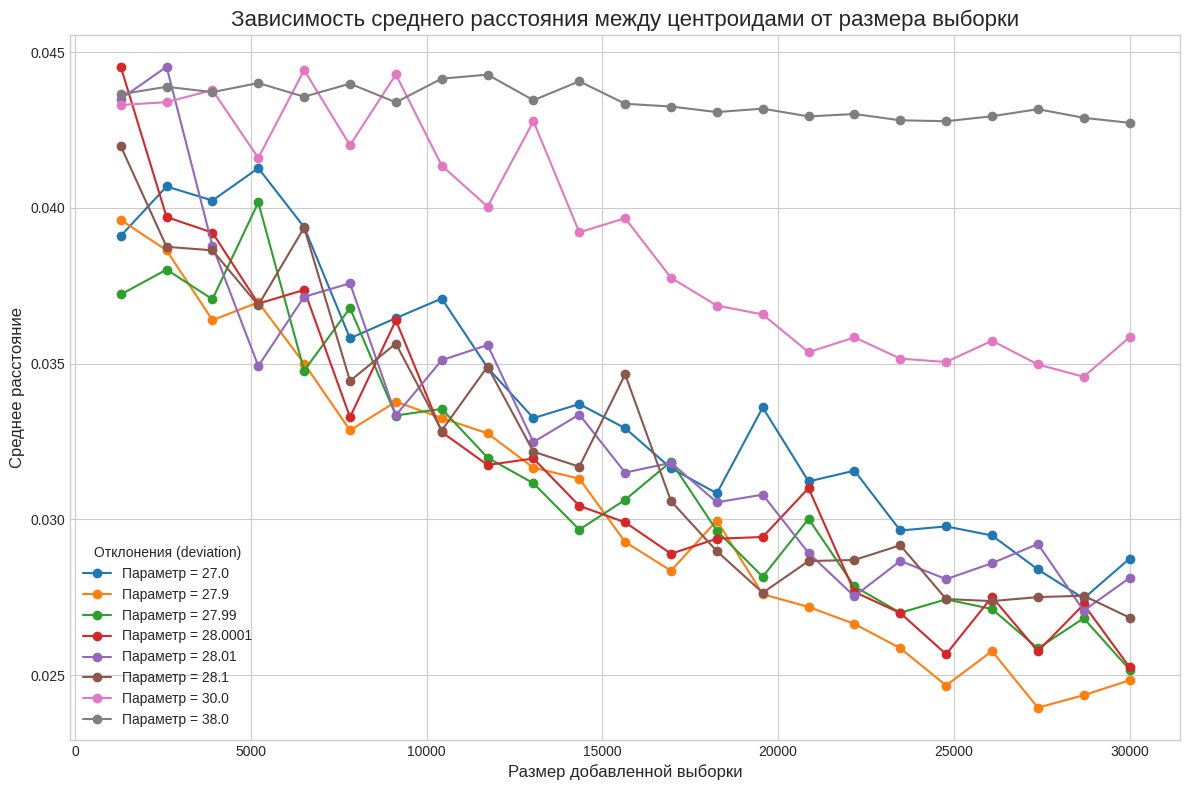

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def create_plot():
    file_path = 'x.txt'

    column_names = ['deviation', 'prediction_size', 'added_size',
                    'experiment', 'base_size', 'avg_distance']

    data = pd.read_csv(file_path, sep=' ', header=None, names=column_names)

    data['deviation'] = pd.to_numeric(data['deviation'])
    data['added_size'] = pd.to_numeric(data['added_size'])
    data['avg_distance'] = pd.to_numeric(data['avg_distance'])

    # Фильтруем данные, убирая строки где added_size равен 0
    filtered_data = data[data['added_size'] != 0].copy()

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))

    # Группируем данные по отклонению и строим график для каждой группы
    for deviation, group in filtered_data.groupby('deviation'):
        sorted_group = group.sort_values('added_size')
        ax.plot(sorted_group['added_size'], sorted_group['avg_distance'], marker='o',
                linestyle='-', label=f'Параметр = {deviation+28}')

    ax.set_title('Зависимость среднего расстояния между центроидами от размера выборки', fontsize=16)
    ax.set_xlabel('Размер добавленной выборки', fontsize=12)
    ax.set_ylabel('Среднее расстояние', fontsize=12)
    ax.legend(title='Отклонения (deviation)', fontsize=10)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('random_name.png')
    plt.show()


if __name__ == '__main__':
    create_plot()